In [488]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [490]:
model = pd.read_csv("dataset_2025-04-12T14_57_48.474195738Z_DEFAULT_INTEGRATION_IMF.STA_CPI_3.0.1.csv", index_col=[5]).transpose()

In [500]:
detailed_model= model.iloc[8:].dropna().copy()
cpi= model['All Items'].copy().iloc[8:]

In [502]:
cpi = pd.DataFrame(cpi)

In [454]:
X=detailed_model.drop('All Items', axis=1)
y=detailed_model['All Items']

In [456]:
model1 = LinearRegression(fit_intercept=False).fit(X, y)

weights = model1.coef_
shares = weights / weights.sum()  # Normalize to sum to 1

In [458]:
component_shares = pd.Series(weights, index = X.columns)

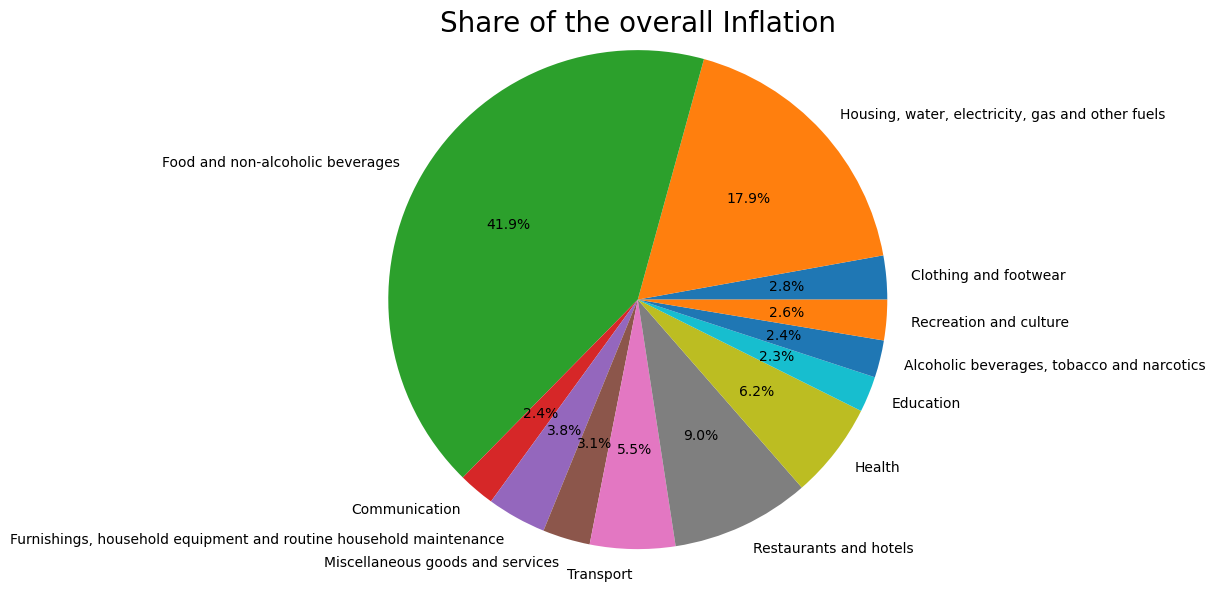

In [460]:
component_shares.plot.pie(figsize=(10,6), autopct = '%1.1f%%',  radius = 1.2, labeldistance=1.1)
plt.title("Share of the overall Inflation", fontsize = 20, color="Black")
plt.tight_layout()
plt.show()

In [538]:
inflation_yoy_quarterly = (cpi.pct_change(periods=4) * 100).dropna()

C:\Users\GegaMukhigulashvili\AppData\Local\Temp\ipykernel_17036\107517530.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inflation_yoy_quarterly = (cpi.pct_change(periods=4) * 100).dropna()


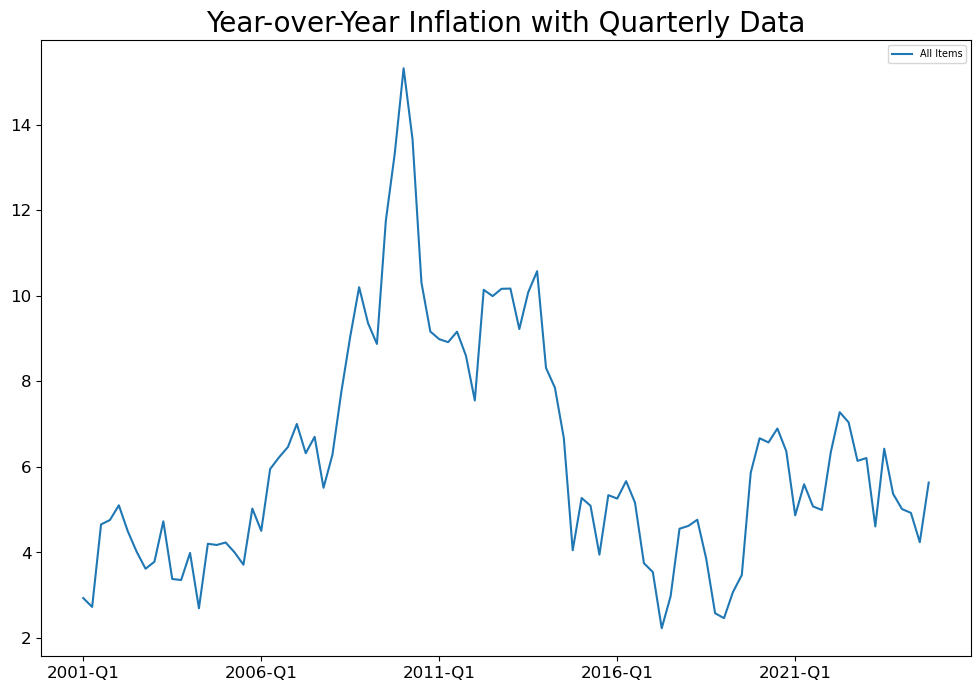

In [556]:
inflation_yoy_quarterly.plot(figsize = (12,8), fontsize=12)
plt.title("Year-over-Year Inflation with Quarterly Data", fontsize = 20, color="Black")
plt.legend(fontsize=7)
plt.show()